<a href="https://colab.research.google.com/github/M-Abbi/Financial-Modeling/blob/main/Brownian_Motion_%2B_Probability_Script_Example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Front Desk Application: Pricing a "Worst-Of" Autocallable Note

To see how Variance, Covariance, and Correlation translate into millions of dollars of active risk management, we look at a classic, high-stakes mechanism on the Structured Products desk: **Structuring a Worst-Of Autocallable Note**.

---

## 1. The Front Desk Scenario: The Exotic Equity Desk

Imagine you are a Structural Quant on the Equity Exotics desk. A high-net-worth wealth management client wants to generate yield in a low-interest-rate environment but refuses to buy equities outright due to market downside fears.

Your desk structures a **3-Year Note** linked to three distinct underlying assets:
1. **Apple (AAPL)** – Technology Growth ($\text{Asset } X$)
2. **ExxonMobil (XOM)** – Energy/Cyclical Value ($\text{Asset } Y$)
3. **Barrick Gold (GOLD)** – Safe-Haven Commodity ($\text{Asset } Z$)

### The Structure Rules:
* **The Payout:** The note promises a highly attractive **$12\%$ annual coupon**, *provided that* none of the three stocks drop below $70\%$ of their starting price (the **Barrier Limit**) at any point over the 3-year term.
* **The Downside Catch:** If even a single stock crashes below that $70\%$ barrier at maturity, the investor’s principal protection evaporates. The investor is penalized by being forced to take physical delivery of the **Worst-Performing Stock** of the three.

The sales team needs an immediate calculation: *How do we evaluate the true probability of a barrier breach to safely price this structured derivative?*

---

## 2. The Quant Analysis: The Correlation Trap

The client assumes this note is incredibly safe because the individual standalone annual volatilities look manageable:
$$\sigma_{\text{AAPL}} = 25\%, \quad \sigma_{\text{XOM}} = 18\%, \quad \sigma_{\text{GOLD}} = 15\%$$

As the desk quant, you know that looking at individual variances in isolation is a catastrophic blind spot. Because the structural payout relies entirely on the **minimum** of the multi-asset system ($\min(X, Y, Z)$), the dominant risk vector is the **Correlation Matrix ($\mathbf{\Sigma}$)**.

### Scenario A: Perfect Positive Correlation ($\rho = +1.0$)
If all three assets move in absolute lockstep, the probability of the "Worst-Of" asset breaching the barrier is exactly equal to the probability of *any single asset* breaching it.
* **Desk Strategy:** Low joint risk. The embedded option we are shorting is cheap to hedge. The coupon we pass to the client will be relatively low.

### Scenario B: Uncorrelated / Negatively Correlated Assets ($\rho \le 0$)
If the assets move independently or in opposition (e.g., Tech rallies, but Gold plunges), the client has essentially given the desk three independent chances to trigger a breach. This is the structural equivalent of playing Russian Roulette with three independent cylinders spinning rather than one.
* **Desk Strategy:** High joint risk. The mathematical probability that *at least one* asset falls through the $70\%$ floor increases dramatically. Because this short-put option is highly likely to finish in the money for the desk, the option is incredibly valuable. We harvest this massive volatility premium to fund the **large $12\%$ coupon** requested by the client.

---

## 3. The Math: Simulating the Joint Probability Space

To accurately map this non-linear dependency path, the desk avoids simple one-dimensional integration. We model the joint asset paths using a **Multivariate Geometric Brownian Motion**, utilizing the covariance structure directly.

The daily returns vector $\mathbf{r}_t = [r_{\text{AAPL}}, r_{\text{XOM}}, r_{\text{GOLD}}]^T$ is driven by the matrix equation:

$$\mathbf{r}_t = \mathbf{\mu} \Delta t + \mathbf{\Sigma}^{1/2} \mathbf{Z}_t$$

Where:
* $\mathbf{\mu}$ represents the vector of expected asset drifts.
* $\mathbf{\Sigma}^{1/2}$ is the square root of the Covariance Matrix, extracted using a **Cholesky Decomposition** ($\mathbf{\Sigma} = \mathbf{L}\mathbf{L}^T$).
* $\mathbf{Z}_t$ is a vector of mutually independent standard normal random shocks:
$$\mathbf{Z}_t \sim N(\mathbf{0}, \mathbf{I})$$

By multiplying the independent random vector $\mathbf{Z}_t$ by the lower triangular Cholesky matrix $\mathbf{L}$, the desk injects the real-world historical correlation structure back into the random simulation paths.£

In [3]:
import numpy as np

def price_worst_of_structured_note(n_simulations=10000, days=252*3):
    """
    Simulates a multi-asset system using a Covariance Matrix and Cholesky
    Decomposition to evaluate the risk of a Worst-Of Structured Product.
    """
    # 1. Desk Parameters
    asset_names = ['Apple (Tech)', 'Exxon (Energy)', 'Barrick (Gold)']
    vols = np.array([0.25, 0.18, 0.15]) # Standalone Annualized Volatilities (Standard Deviations)
    drifts = np.array([0.05, 0.02, 0.01]) # Annual expected returns
    barrier_level = 0.70 # 70% of initial price

    # 2. Define the Real-World Low Correlation Matrix (The Diversification Trap)
    # Notice the decoupling between Tech, Energy, and Gold
    corr_matrix = np.array([
        [ 1.00,  0.10, -0.20],  # Apple vs others
        [ 0.10,  1.00,  0.05],  # Exxon vs others
        [-0.20,  0.05,  1.00]   # Gold vs others
    ])

    # 3. Construct the Covariance Matrix (Sigma = D * R * D)
    D = np.diag(vols)
    Sigma_annual = D @ corr_matrix @ D

    # Scale to daily parameters
    dt = 1 / 252
    Sigma_daily = Sigma_annual * dt
    daily_drifts = (drifts - 0.5 * vols**2) * dt

    # 4. Linear Algebra Engine: Cholesky Decomposition (L)
    # L is the lower triangular matrix such that L * L^T = Sigma
    # This is the mathematical key to generating correlated random variables!
    L = np.linalg.cholesky(Sigma_daily)

    # 5. Run Monte Carlo Simulation
    barrier_breaches = 0
    final_payouts = []

    for sim in range(n_simulations):
        # Generate independent daily random normal shocks for 3 assets
        Z = np.random.normal(0, 1, size=(3, days))

        # Transform independent shocks into CORRELATED shocks using our matrix engine
        correlated_shocks = L @ Z

        # Simulate price paths using Geometric Brownian Motion equations
        # Reshape daily_drifts to (3, 1) for correct broadcasting with correlated_shocks (3, days)
        price_ratios = np.exp(daily_drifts[:, np.newaxis] + correlated_shocks)
        price_paths = np.cumprod(price_ratios, axis=1)

        # Check the final prices at maturity (day 3) relative to start (1.0)
        final_prices = price_paths[:, -1]
        worst_performing_asset_performance = np.min(final_prices)

        # Check if the WORST-performing asset breached the client's 70% safety barrier
        if worst_performing_asset_performance < barrier_level:
            barrier_breaches += 1

    breach_probability = barrier_breaches / n_simulations

    print("=========================================================")
    print("         EXOTICS DESK RISK VALUATION REPORT              ")
    print("=========================================================")
    print(f"Structure Horizon  : 3 Years ({days} trading days)")
    print(f"Barrier Protection : {barrier_level*100:.0f}% of Initial Strike")
    print("---------------------------------------------------------")
    print(f"Probability of Worst-Of Barrier Breach: {breach_probability*100:.2f}%")
    print("=========================================================")
    print("DESK RECOMMENDATION:")
    if breach_probability > 0.40:
        print("--> HIGH TAIL RISK: The low asset correlation creates an excellent")
        print("    options harvest. We can comfortably offer the client a 12% coupon")
        print("    because our desk has a high probability of pocketing the residual asset.")
    else:
        print("--> LOW TAIL RISK: Assets are moving together. Reduce the coupon offer.")
    print("=========================================================")

price_worst_of_structured_note()

         EXOTICS DESK RISK VALUATION REPORT              
Structure Horizon  : 3 Years (756 trading days)
Barrier Protection : 70% of Initial Strike
---------------------------------------------------------
Probability of Worst-Of Barrier Breach: 33.29%
DESK RECOMMENDATION:
--> LOW TAIL RISK: Assets are moving together. Reduce the coupon offer.


## 4. Visualizing the Correlation Trap

To fully grasp the mechanics of a "Worst-Of" structure, we must visualize the joint asset paths. The Python script below runs a Monte Carlo simulation, maps out the path of each asset over a 3-year horizon through our Cholesky-derived Covariance engine, and explicitly highlights the **Worst-Of performance envelope**.

Notice how a single asset dropping below the $70\%$ barrier (the red dashed line) instantly ruins the principal protection for the entire structure, even if the other two assets are performing exceptionally well.

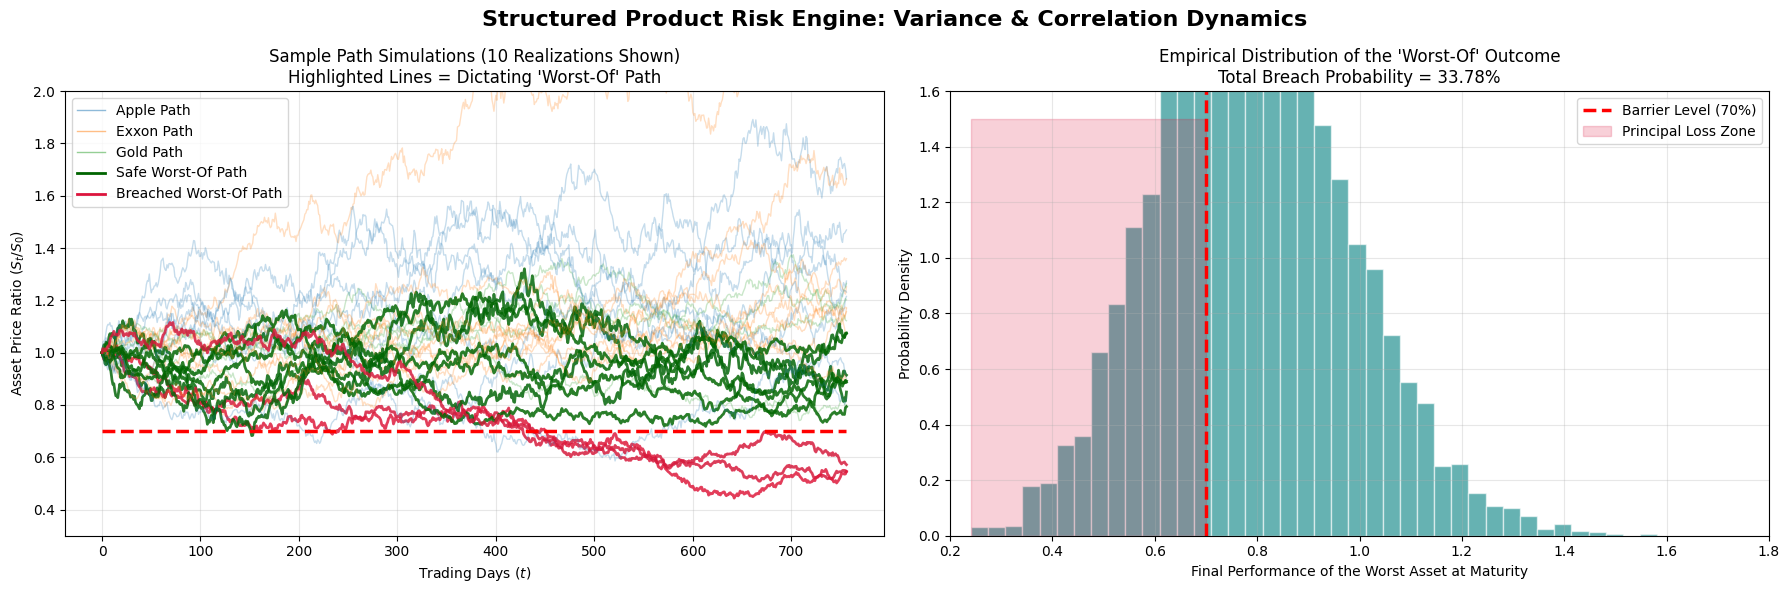

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def run_visual_structured_note_simulation(n_paths_to_plot=10, n_simulations=5000):
    # 1. Setup Parameters (3 Years of trading days)
    days = 252 * 3
    asset_names = ['Apple (Tech)', 'Exxon (Energy)', 'Barrick (Gold)']
    vols = np.array([0.25, 0.18, 0.15])
    drifts = np.array([0.05, 0.02, 0.01])
    barrier_level = 0.70

    # Low correlation matrix (uncorrelated assets widen the "Worst-Of" downside distribution)
    corr_matrix = np.array([
        [ 1.00,  0.10, -0.20],
        [ 0.10,  1.00,  0.05],
        [-0.20,  0.05,  1.00]
    ])

    # 2. Build Covariance Matrix & Extract Cholesky Factor
    D = np.diag(vols)
    Sigma_annual = D @ corr_matrix @ D
    dt = 1 / 252
    Sigma_daily = Sigma_annual * dt
    daily_drifts = (drifts - 0.5 * vols**2) * dt
    L = np.linalg.cholesky(Sigma_daily)

    # 3. Storage arrays for plotting and analytics
    np.random.seed(42)
    worst_of_finals = []
    barrier_breaches = 0

    # Setup Figure Layout
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
    fig.suptitle("Structured Product Risk Engine: Variance & Correlation Dynamics", fontsize=16, fontweight='bold')

    # 4. Run Simulation & Plot Sample Paths
    for sim in range(n_simulations):
        Z = np.random.normal(0, 1, size=(3, days))
        correlated_shocks = L @ Z
        price_ratios = np.exp(daily_drifts[:, None] + correlated_shocks)

        # Stacking starting price of 1.0 at day 0
        paths = np.hstack([np.ones((3, 1)), np.cumprod(price_ratios, axis=1)])

        # Track tracking parameters
        final_prices = paths[:, -1]
        worst_asset_perf = np.min(final_prices)
        worst_of_finals.append(worst_asset_perf)

        if worst_asset_perf < barrier_level:
            barrier_breaches += 1

        # Plot the first few sample paths visually on the left graph
        if sim < n_paths_to_plot:
            time_axis = np.arange(days + 1)
            # Find which asset was the worst for this particular path run
            worst_asset_idx = np.argmin(final_prices)

            # Plot the individual asset lines lightly
            ax1.plot(time_axis, paths[0], color='tab:blue', alpha=0.25, lw=1)
            ax1.plot(time_axis, paths[1], color='tab:orange', alpha=0.25, lw=1)
            ax1.plot(time_axis, paths[2], color='tab:green', alpha=0.25, lw=1)

            # Highlight the actual "Worst-Of" trajectory that dictates the contract payout
            worst_path = paths[worst_asset_idx]
            color_payout = 'crimson' if worst_asset_perf < barrier_level else 'darkgreen'
            ax1.plot(time_axis, worst_path, color=color_payout, lw=2, alpha=0.8)

    # 5. Format Left Plot (Monte Carlo Paths)
    # Adding manual legend handles to prevent duplicates
    from matplotlib.lines import Line2D
    custom_lines = [Line2D([0], [0], color='tab:blue', alpha=0.5, lw=1),
                    Line2D([0], [0], color='tab:orange', alpha=0.5, lw=1),
                    Line2D([0], [0], color='tab:green', alpha=0.5, lw=1),
                    Line2D([0], [0], color='darkgreen', lw=2),
                    Line2D([0], [0], color='crimson', lw=2)]

    # Correcting the Line2D constructor call for the barrier line
    ax1.add_line(Line2D([0, days], [barrier_level, barrier_level], color='red', linestyle='--', lw=2.5))
    ax1.set_title(f"Sample Path Simulations ({n_paths_to_plot} Realizations Shown)\nHighlighted Lines = Dictating 'Worst-Of' Path")
    ax1.set_xlabel("Trading Days ($t$)")
    ax1.set_ylabel("Asset Price Ratio ($S_t / S_0$)")
    ax1.legend(custom_lines, ['Apple Path', 'Exxon Path', 'Gold Path', 'Safe Worst-Of Path', 'Breached Worst-Of Path'], loc='upper left')
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim(0.3, 2.0)

    # 6. Format Right Plot (Worst-Of Density Distribution)
    breach_prob = barrier_breaches / n_simulations
    ax2.hist(worst_of_finals, bins=40, density=True, color='teal', alpha=0.6, edgecolor='white')
    ax2.axvline(barrier_level, color='red', linestyle='--', linewidth=2.5, label=f'Barrier Level ({barrier_level*100:.0f}%)')

    # Shade the loss breach zone red
    x_axis = np.linspace(min(worst_of_finals), barrier_level, 100)
    ax2.fill_between(x_axis, 0, 1.5, color='crimson', alpha=0.2, label='Principal Loss Zone')

    ax2.set_title(f"Empirical Distribution of the 'Worst-Of' Outcome\nTotal Breach Probability = {breach_prob*100:.2f}%")
    ax2.set_xlabel("Final Performance of the Worst Asset at Maturity")
    ax2.set_ylabel("Probability Density")
    ax2.set_xlim(0.2, 1.8)
    ax2.set_ylim(0, 1.6)
    ax2.legend(loc='upper right')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

run_visual_structured_note_simulation()